# 1st step :
**setting up google colab and uploading the dataset**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
sns.set(style="whitegrid")


In [6]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


In [8]:
df = pd.read_csv("Mall_Customers.csv")
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


# 2nd step
**EDA**

In [9]:
df.shape

(200, 5)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [14]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [15]:
df.duplicated().sum()

np.int64(0)

# 3rd step
**visualization**

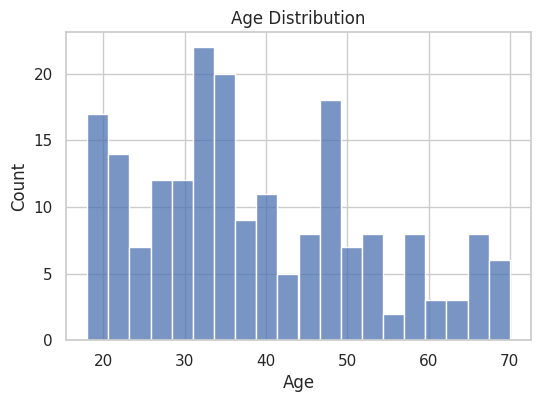

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"],bins=20)
plt.title("Age Distribution")
plt.show()

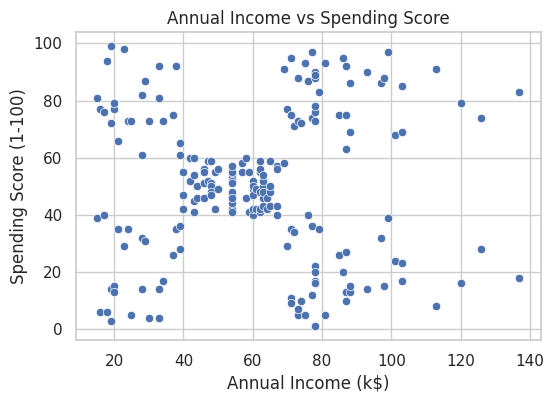

In [19]:
plt.figure(figsize=(6,4))
sns.scatterplot(x = "Annual Income (k$)", y = "Spending Score (1-100)",data=df)
plt.title("Annual Income vs Spending Score")
plt.show()

# 4th step
feature selection for clustering

In [22]:
x = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# 5th step
**scaling**

In [24]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x) #because k-means depends on distance

# 6th step
**finding the optimal numbers of clusters (elbow method)**


In [31]:
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters = i,random_state = 42)
  kmeans.fit(x_scaled)
  wcss.append(kmeans.inertia_)

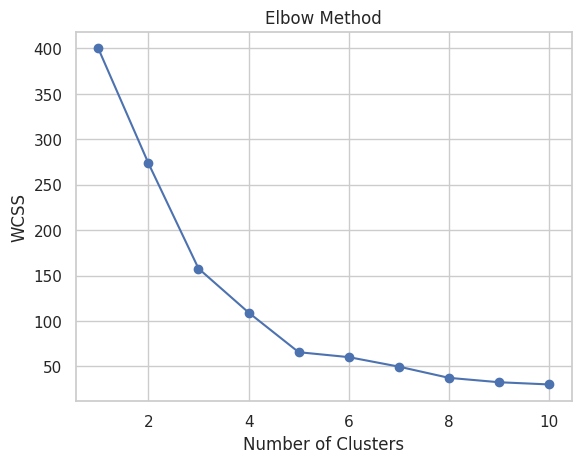

In [32]:
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# 7th step
**training**

In [33]:
kmeans = KMeans(n_clusters = 5,random_state = 42)
clusters = kmeans.fit_predict(x_scaled)
df["cluster"] = clusters

# 8th step
**visualize clusters**

<function matplotlib.pyplot.show(close=None, block=None)>

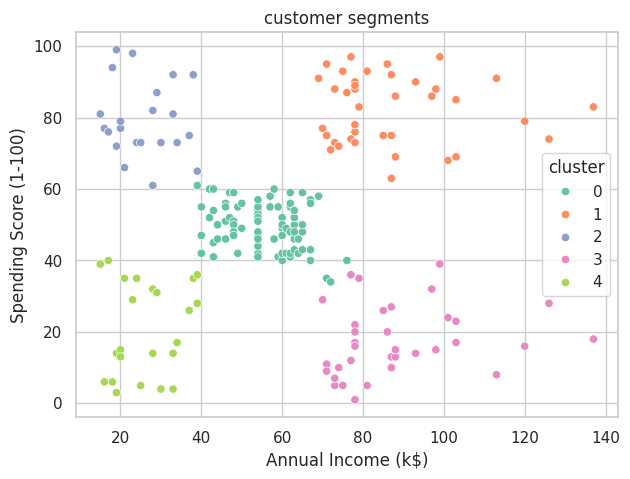

In [37]:
plt.figure(figsize=(7,5))
sns.scatterplot(x = "Annual Income (k$)", y = "Spending Score (1-100)",hue = "cluster",palette = "Set2",data = df)
plt.title("customer segments")
plt.show

In [42]:
df.groupby("cluster").mean(numeric_only=True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,,
0,86.320988,42.716049,55.296296,49.518519
1,162.000000,32.692308,86.538462,82.128205
2,23.090909,25.272727,25.727273,79.363636
3,164.371429,41.114286,88.200000,17.114286
4,23.000000,45.217391,26.304348,20.913043


In [44]:
cluster_names = {
    0: "Average Customers",
    1: "VIP Customers",
    2: "Young Spenders",
    3: "High Income Low Spending",
    4: "Budget Customers"
}

df["Customer Segment"] = df["cluster"].map(cluster_names)

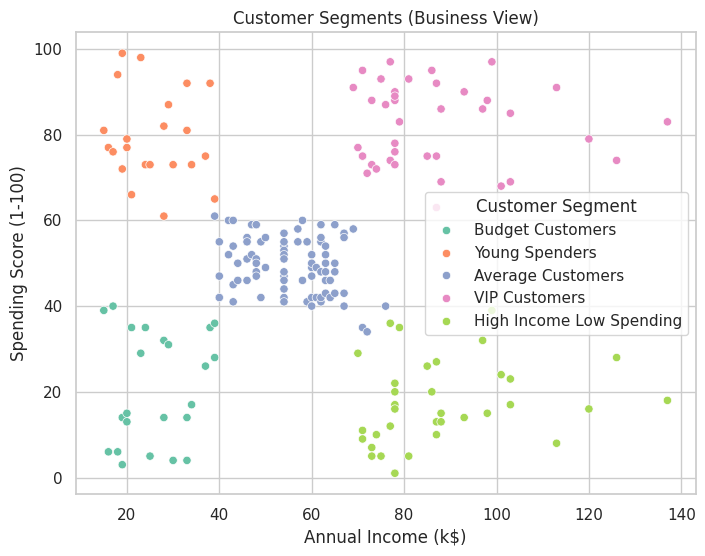

In [45]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Customer Segment",
    data=df,
    palette="Set2"
)
plt.title("Customer Segments (Business View)")
plt.show()

Business Insights & Recommendations

Based on customer segmentation using K-Means clustering, five distinct customer groups were identified:

1. VIP Customers (High Income, High Spending)

Represent the most valuable customer segment.

Recommendation: Offer loyalty programs, exclusive discounts, and premium memberships to retain them.

2. High Income – Low Spending Customers

Have strong purchasing power but low engagement.

Recommendation: Targeted marketing campaigns and personalized promotions may increase spending.

3. Young High-Spending Customers

Younger demographic with strong spending behavior.

Recommendation: Focus on social media marketing and trend-based promotions.

4. Average Customers

Moderate income and spending behavior.

Recommendation: Maintain engagement through seasonal offers.

5. Budget Customers

Low income and low spending patterns.

Recommendation: Provide discounts and bundle deals to encourage purchases.